In [1]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.1/281.1 kB 2.2 MB/s eta 0:00:0000:0100:01


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Get LeBron's player information and seasons

In [3]:
import pandas as pd
pd.options.display.max_columns = None

from nba_api.stats.endpoints import commonplayerinfo

player_info = commonplayerinfo.CommonPlayerInfo(player_id=2544)
lebron_season_df = player_info.available_seasons.get_data_frame()
lebron_season_df['SEASON_ID'] = lebron_season_df[lebron_season_df['SEASON_ID'].str.startswith('1') | lebron_season_df['SEASON_ID'].str.startswith('2')]
lebron_season_df = lebron_season_df[lebron_season_df['SEASON_ID'].notnull()]

# Let's get all the season ids to a list
seasons = lebron_season_df['SEASON_ID'].to_list()

# Get all games played

In [4]:
from nba_api.stats.endpoints import playergamelog

all_games_df = pd.DataFrame()

for season in seasons:
    season_year = season[1:5]  # Extract the year part from SEASON_ID (e.g., '2003' from '12003')
    next_year = str(int(season_year) + 1)[-2:]  # Get the last two digits of the next year (e.g., '04')
    
    season_str = f"{season_year}-{next_year}"  # Format season as 'YYYY-YY' (e.g., '2003-04')
    
    game_log = playergamelog.PlayerGameLog(player_id=2544, season=season_str)
    game_df = game_log.get_data_frames()[0]
    all_games_df = pd.concat([all_games_df, game_df], ignore_index=True)

all_games_df

,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22003,2544,0020301179,"APR 14, 2004",CLE @ NYK,W,35,8,17,0.471,0,3,0.000,1,1,1.000,0,1,1,5,3,0,5,1,17,-6,0
1,22003,2544,0020301162,"APR 12, 2004",CLE vs. MIL,W,45,9,20,0.450,1,4,0.250,8,11,0.727,1,6,7,9,2,0,1,1,27,11,0
2,22003,2544,0020301151,"APR 10, 2004",CLE vs. MIA,W,32,4,11,0.364,0,2,0.000,2,5,0.400,1,2,3,11,0,0,2,3,10,14,0
3,22003,2544,0020301137,"APR 09, 2004",CLE @ MIA,L,42,6,14,0.429,1,1,1.000,11,15,0.733,1,6,7,8,1,0,8,2,24,-16,0
4,22003,2544,0020301128,"APR 07, 2004",CLE @ MEM,L,36,4,11,0.364,0,0,0.000,6,7,0.857,0,3,3,5,3,0,2,4,14,-11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2979,22023,2544,0022300127,"NOV 01, 2023",LAL vs. LAC,W,42,13,19,0.684,4,8,0.500,5,10,0.500,0,12,12,7,1,2,4,3,35,6,1
2980,22023,2544,0022300111,"OCT 30, 2023",LAL vs. ORL,W,33,7,17,0.412,2,6,0.333,3,4,0.750,0,3,3,4,3,1,5,0,19,5,1
2981,22023,2544,0022300100,"OCT 29, 2023",LAL @ SAC,L,39,11,19,0.579,3,8,0.375,2,6,0.333,0,15,15,8,0,0,8,2,27,-5,1
2982,22023,2544,0022300076,"OCT 26, 2023",LAL vs. PHX,W,35,7,14,0.500,1,5,0.200,6,8,0.750,1,7,8,9,2,2,5,1,21,22,1


In [5]:
all_games_df.columns

Index(['SEASON_ID', 'Player_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL',
       'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE'],
      dtype='object')

# Exploratory Data Analysis 

(kind of useless right now but whatever)

In [6]:
# # Correlation matrix
# correlation_matrix = all_games_df.corr()

# # Plot a heatmap of the correlation matrix
# plt.figure(figsize=(20, 20))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
# plt.title('Correlation Matrix')
# plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


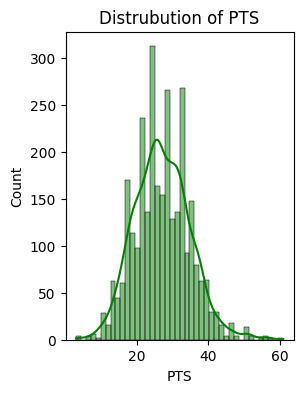

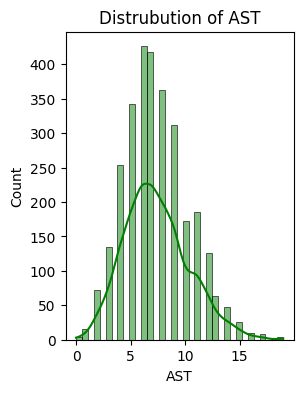

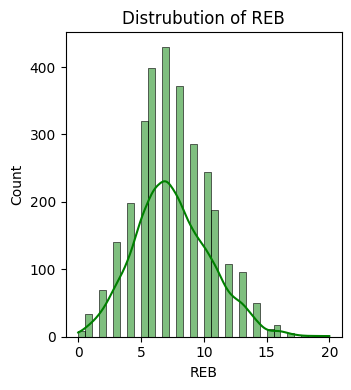

In [7]:
df = pd.DataFrame()
df['PTS'] = all_games_df['PTS']
df['AST'] = all_games_df['AST']
df['REB'] = all_games_df['REB']

# Plot the distribution of the target variables
for i, col in enumerate(df.columns):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='green')
    plt.title('Distrubution of ' + col)

plt.tight_layout()
plt.show()

# Drop unnecessary columns

In [8]:
cols_to_drop = ['SEASON_ID', 'Game_ID', 'VIDEO_AVAILABLE', 'WL']
all_games_df.drop(columns=cols_to_drop, inplace=True)

# Divide categorical and continuous columns

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

LE = LabelEncoder()
SS = StandardScaler()
categorical = ['GAME_DATE', 'MATCHUP']
continuous = ['MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'PLUS_MINUS']
for col in categorical:
    all_games_df[col] = LE.fit_transform(all_games_df[col])
for col in continuous:
    all_games_df[col] = SS.fit_transform(all_games_df[col].values.reshape(-1, 1))

In [10]:
all_games_df.isnull().sum()

Player_ID     0
GAME_DATE     0
MATCHUP       0
MIN           0
FGM           0
FGA           0
FG_PCT        0
FG3M          0
FG3A          0
FG3_PCT       0
FTM           0
FTA           0
FT_PCT        0
OREB          0
DREB          0
REB           0
AST           0
STL           0
BLK           0
TOV           0
PF            0
PTS           0
PLUS_MINUS    0
dtype: int64

# Prepare the training and validation datasets

In [11]:
from sklearn.model_selection import train_test_split

y = all_games_df[continuous]
X = all_games_df[['GAME_DATE', 'MATCHUP', 'Player_ID']]
X = pd.get_dummies(X, columns=['Player_ID'], drop_first=True)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42)

# Training the different models

In [12]:
# Create and train the multi-target regression model (ElasticNet)
multioutput_model = MultiOutputRegressor(
    ElasticNet(alpha=0.5, l1_ratio=0.5), n_jobs=5)
multioutput_model.fit(X_train, y_train)

# Create and train the decision tree regressor model
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

# Create and train the random forest regressor model
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# Predicting

In [13]:
# Multioutput predictions
multioutput_preds = multioutput_model.predict(X_valid)
# Tree predictions
tree_preds = tree_model.predict(X_valid)
# Random forest predictions
forest_preds = forest_model.predict(X_valid)

# Print the error for each variable

In [14]:
# Unscale the predictions as we used StandardScaler to make the difference between variable value range null
tree_preds = SS.inverse_transform(tree_preds)
multioutput_preds = SS.inverse_transform(tree_preds)
forest_preds = SS.inverse_transform(tree_preds)

In [15]:
tree_preds.shape, y_valid.shape

((746, 20), (746, 20))

In [16]:
y_valid.columns

Index(['MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'PLUS_MINUS'],
      dtype='object')

In [23]:
forests_mae = []
trees_mae = []
multioutputs_mae = []
for i in range(len(continuous)):
    tree_mae = mean_absolute_error(y_valid.iloc[:, i], tree_preds[:, i])
    trees_mae.append(tree_mae)
    print(f"TREE_MAE for {continuous[i]}: {tree_mae}")
    multioutput_mae = mean_absolute_error(y_valid.iloc[:, i], multioutput_preds[:, i])
    multioutputs_mae.append(multioutput_mae)
    print(f"MULTIOUTPUT_MAE for {continuous[i]}: {multioutput_mae}")
    forest_mae = mean_absolute_error(y_valid.iloc[:, i], forest_preds[:, i])
    forests_mae.append(forest_mae)
    print(f"FOREST_MAE for {continuous[i]}: {forest_mae}")
    print(f"------------------------------------------------")

TREE_MAE for MIN: 10.401617765431263
MULTIOUTPUT_MAE for MIN: 140.42592165662927
FOREST_MAE for MIN: 140.42592165662927
------------------------------------------------
TREE_MAE for FGM: 10.17383921557067
MULTIOUTPUT_MAE for FGM: 137.29559583342024
FOREST_MAE for FGM: 137.29559583342024
------------------------------------------------
TREE_MAE for FGA: 10.145435144208745
MULTIOUTPUT_MAE for FGA: 137.10648991349854
FOREST_MAE for FGA: 137.10648991349854
------------------------------------------------
TREE_MAE for FG_PCT: 9.83252560059596
MULTIOUTPUT_MAE for FG_PCT: 132.75079844829378
FOREST_MAE for FG_PCT: 132.75079844829378
------------------------------------------------
TREE_MAE for FG3M: 8.985738019297967
MULTIOUTPUT_MAE for FG3M: 121.07745274454014
FOREST_MAE for FG3M: 121.07745274454014
------------------------------------------------
TREE_MAE for FG3A: 9.829003163202524
MULTIOUTPUT_MAE for FG3A: 133.65415192817954
FOREST_MAE for FG3A: 133.65415192817954
-------------------------

# Visualizing the performance of each model

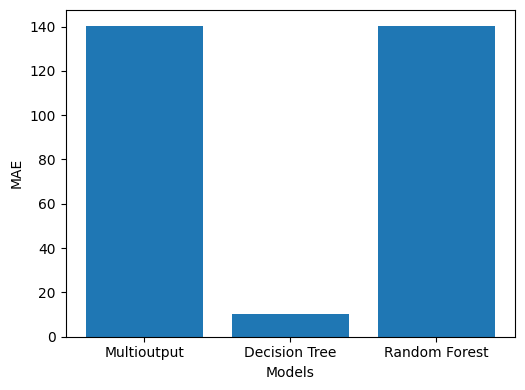

In [26]:
plt.figure(figsize=(10, 4))
models = ['Multioutput', 'Decision Tree', 'Random Forest']
mae_scores = [multioutputs_mae[0], trees_mae[0], forests_mae[0]]

plt.subplot(1, 2, 1)
plt.bar(models, mae_scores)
plt.xlabel('Models')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()